# Time Series Forecasting Hands On

Topics to cover:
  - Multivariate arima
  - arima exogenous variables
- exponential smoothing (ETS)
- Kalman filters
- Prophet (changepoints)
  - changepoints
- LSTM
- Causal Inference
  - Causal Impact

## StatsModels

### Decomposition

We will start with an example dataset, and try to predict the future.

In [3]:
shampoo_sales = [{"Month": "1-01", "Sales": 266.0},{"Month": "1-02", "Sales": 145.9},{"Month": "1-03", "Sales": 183.1},{"Month": "1-04", "Sales": 119.3},{"Month": "1-05", "Sales": 180.3},{"Month": "1-06", "Sales": 168.5},{"Month": "1-07", "Sales": 231.8},{"Month": "1-08", "Sales": 224.5},{"Month": "1-09", "Sales": 192.8},{"Month": "1-10", "Sales": 122.9},{"Month": "1-11", "Sales": 336.5},{"Month": "1-12", "Sales": 185.9},{"Month": "2-01", "Sales": 194.3},{"Month": "2-02", "Sales": 149.5},{"Month": "2-03", "Sales": 210.1},{"Month": "2-04", "Sales": 273.3},{"Month": "2-05", "Sales": 191.4},{"Month": "2-06", "Sales": 287.0},{"Month": "2-07", "Sales": 226.0},{"Month": "2-08", "Sales": 303.6},{"Month": "2-09", "Sales": 289.9},{"Month": "2-10", "Sales": 421.6},{"Month": "2-11", "Sales": 264.5},{"Month": "2-12", "Sales": 342.3},{"Month": "3-01", "Sales": 339.7},{"Month": "3-02", "Sales": 440.4},{"Month": "3-03", "Sales": 315.9},{"Month": "3-04", "Sales": 439.3},{"Month": "3-05", "Sales": 401.3},{"Month": "3-06", "Sales": 437.4},{"Month": "3-07", "Sales": 575.5},{"Month": "3-08", "Sales": 407.6},{"Month": "3-09", "Sales": 682.0},{"Month": "3-10", "Sales": 475.3},{"Month": "3-11", "Sales": 581.3},{"Month": "3-12", "Sales": 646.9}]

In [33]:
import pandas
df = pandas.DataFrame(shampoo_sales)

df.index = df.Month.apply(lambda x: pandas.to_datetime('202'+x, format="%Y-%m"))
df.index = pandas.DatetimeIndex(df.index.values, freq=df.index.inferred_freq)
df.drop(columns=["Month"], inplace=True)
df.head(3)

,Sales
2021-01-01,266.0
2021-02-01,145.9
2021-03-01,183.1


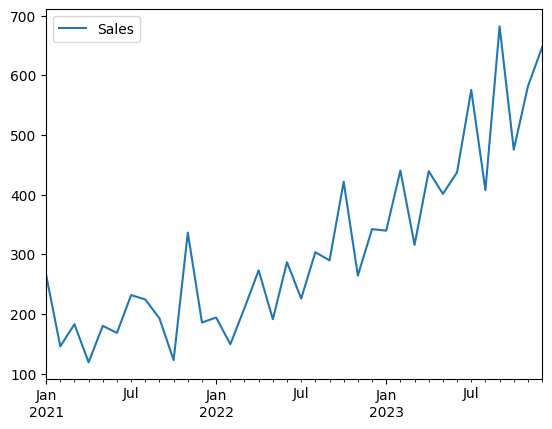

In [34]:
_ = df.plot()

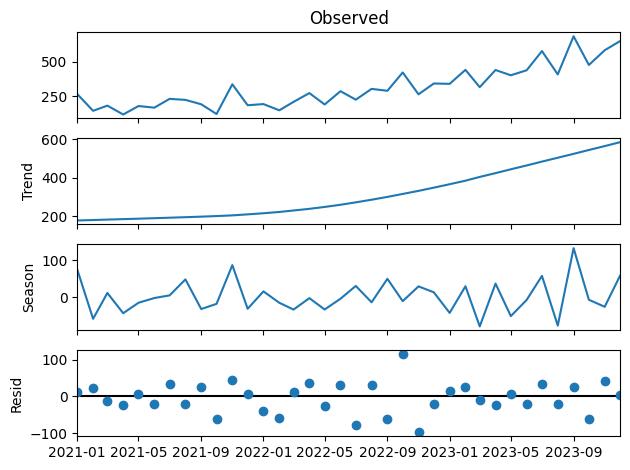

In [35]:
# the first thing we want to do is decompose the data into trent, season, and obtain the residuals from that
from statsmodels.tsa.seasonal import STL
stl = STL(df, seasonal=13)
res = stl.fit()
_ = res.plot()

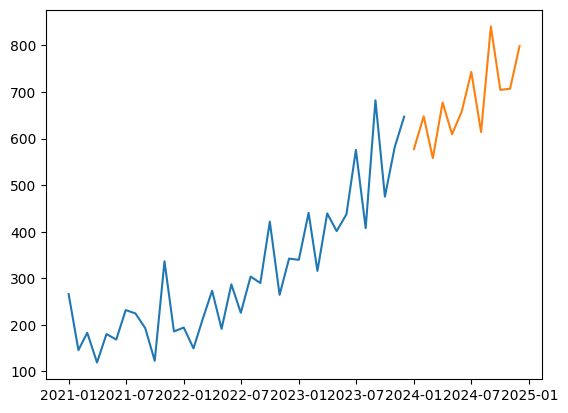

In [36]:
# and we can forecast with the decomposition directly using for example ARIMA
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.forecasting.stl import STLForecast
from matplotlib import pyplot as plt
stlf = STLForecast(df, ARIMA, model_kwargs=dict(order=(1, 1, 0), trend="t"))
stlf_res = stlf.fit()
forecast = stlf_res.forecast(12)
plt.plot(df)
plt.plot(forecast)
plt.show()

### Box-Jenkins Method

Statsmodels implements the Box-Jenkins method for forecasting. It includes checks of the stationarity of the data, identifies seasonality, and decides which (autoregressive or moving average) model to use. It does the parameter estimation, and checks if the model conforms to the expected distribution.

In [37]:
# and we can get details about the model
stlf_res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                    STL Decomposition and SARIMAX Results                     
==============================================================================
Dep. Variable:                      y   No. Observations:                   36
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -185.393
Date:                Thu, 16 Apr 2026   AIC                            376.787
Time:                        17:54:53   BIC                            381.453
Sample:                    01-01-2021   HQIC                           378.397
                         - 12-01-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1            11.7253      4.795      2.445      0.014       2.327      21.123
ar.L1         -0.7200      0.090     -7.970      0.000      -0.897      -0.543
sigma2      2287.6508    647.525      3.533      0.000    1018.524    3556.777
===================================================================================
Ljung-Box (L1) (Q):                   0.54   Jarque-Bera (JB):                 0.70
Prob(Q):                              0.46   Prob(JB):                         0.70
Heteroskedasticity (H):               1.28   Skew:                             0.24
Prob(H) (two-sided):                  0.67   Kurtosis:                         2.50
                                STL Configuration                                
=================================================================================
Period:                            12       Trend Length:                      23
Seasonal:                           7       Trend deg:                          1
Seasonal deg:                       1       Trend jump:                         1
Seasonal jump:                      1       Low pass:                          13
Robust:                         False       Low pass deg:                       1
---------------------------------------------------------------------------------

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### ARIMA assumptions

Arima assumes the data is stationary. That means that when we remove the trend and seasonality, we should be be left with a series that respects some statistical distribution. A common check is testing if the residual is normally distributed

# Auto Regression

In [46]:
from statsmodels.tsa.ar_model import AutoReg
mod = AutoReg(df, lags=3, trend='ct', seasonal=True, period=12)
res = mod.fit(cov_type="HC0")
print(res.summary())

                            AutoReg Model Results                             
Dep. Variable:                  Sales   No. Observations:                   36
Model:               Seas. AutoReg(3)   Log Likelihood                -178.758
Method:               Conditional MLE   S.D. of innovations             54.487
Date:                Thu, 16 Apr 2026   AIC                            391.516
Time:                        18:03:58   BIC                            416.956
Sample:                    04-01-2021   HQIC                           400.076
                         - 12-01-2023                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -30.9918     24.574     -1.261      0.207     -79.156      17.173
trend          9.4673      2.739      3.456      0.001       4.098      14.836
s(2,12)       24.4421     66.406      0.368      0.7

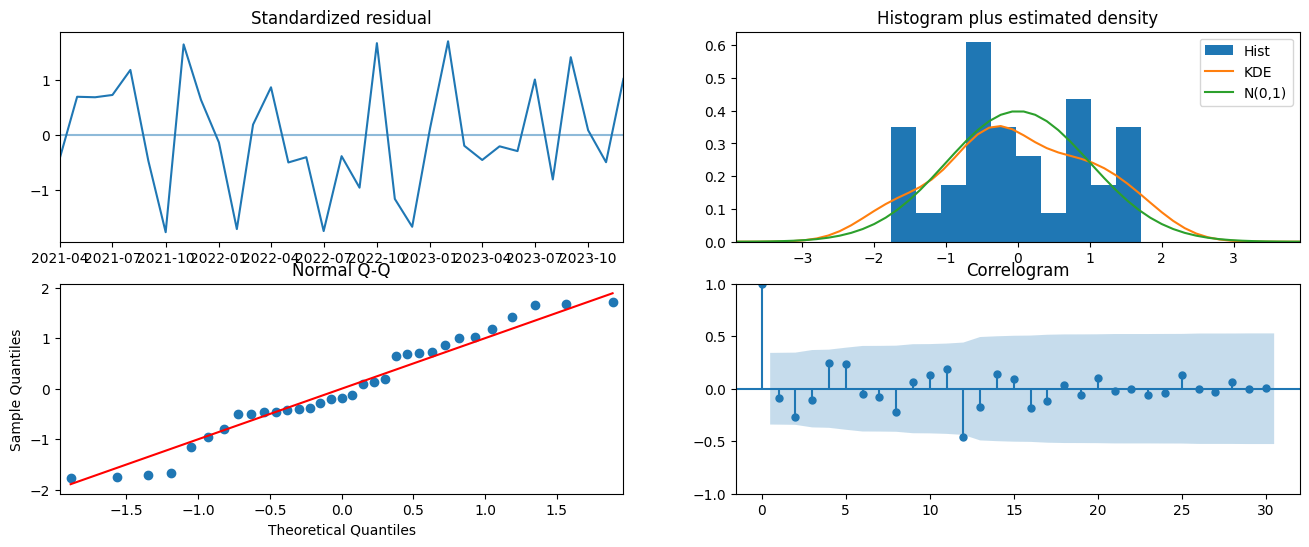

In [52]:
# statsmodels supports diagnostics plots
_ = res.plot_diagnostics(fig=plt.figure(figsize=(16, 6)),lags=30)

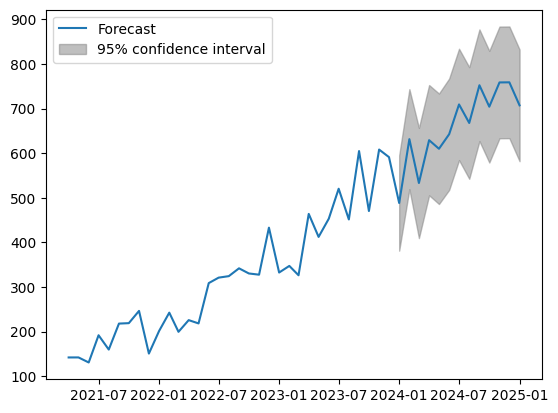

In [53]:
# and it allows us to plot forecasts
_ = res.plot_predict(0, 48)

### Additional Regressors (more features to predict the target variable)

TODO explain the need to know the future values of the regressors, and how to do that (forecasting the regressors, or using known future values)

### Multivariate (multiple interrelated time series)

TODO implement stocks example

## Prophet

In [88]:
from prophet import Prophet
m = Prophet(seasonality_mode='multiplicative')
prophet_df = df.reset_index().rename(columns={"index": "ds", "Sales": "y"})
_ = m.fit(prophet_df)

18:19:25 - cmdstanpy - INFO - Chain [1] start processing
18:19:25 - cmdstanpy - INFO - Chain [1] done processing


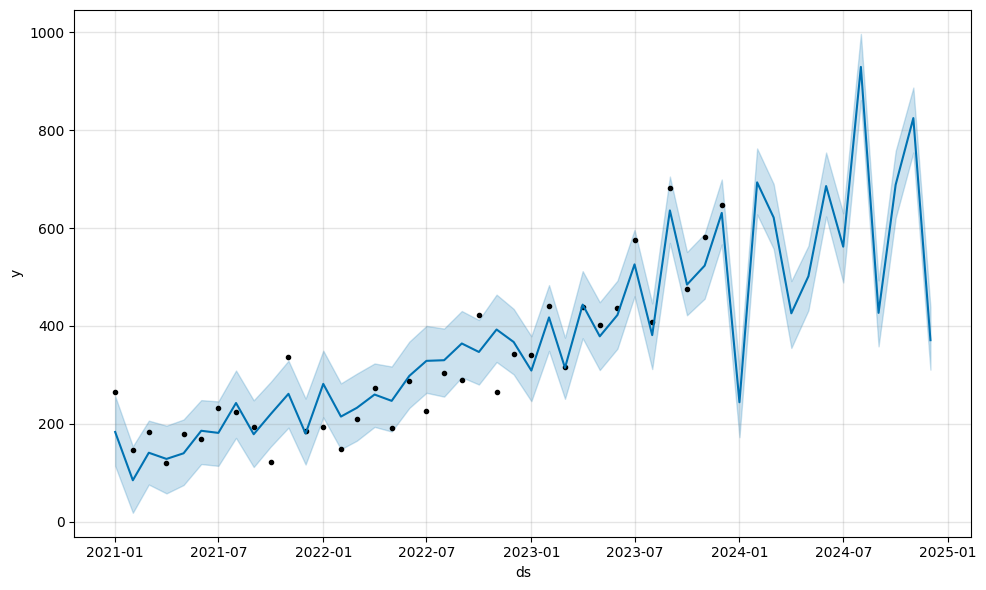

In [89]:
future = m.make_future_dataframe(periods=12, freq='MS')
forecast = m.predict(future)
_ = m.plot(forecast)

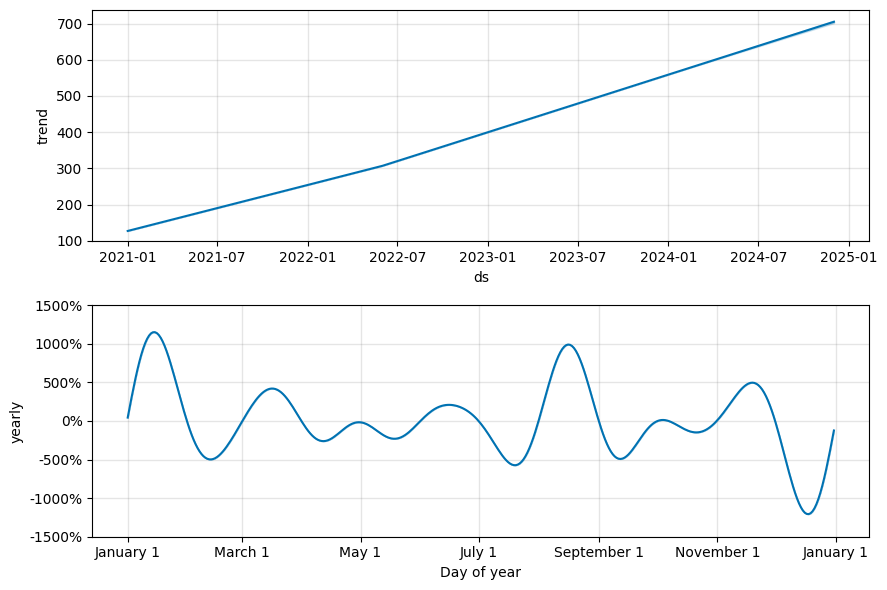

In [91]:
# and we can also plot the components of the forecast
_ = m.plot_components(forecast)